In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


LIF period: 1.0986
FHN period: 39.4744
max R: 0.2847 at phi = 0.895
min R: -0.118 at phi = 0.305
R < 0 from phi = 0.22 to 0.795


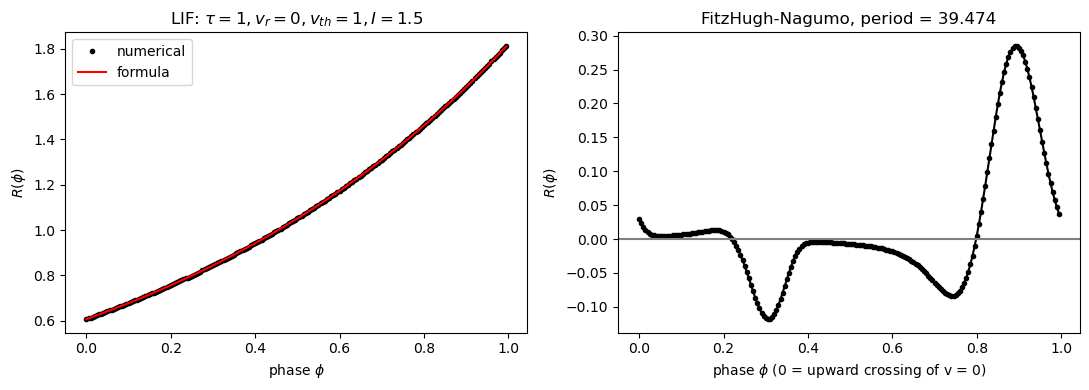

In [2]:
# APPM 4370 HW3, Problem 2(c): measuring PRCs by kicking the voltage
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

delta = 0.001                                  # size of the kick
phis = np.linspace(0, 1, 200, endpoint=False)  # phases to test


D = np.log(1.5 / 0.5)

R_lif = []
for phi in phis:
    t_kick = phi * D                          
    v = 1.5 - 1.5 * np.exp(-t_kick)           
    v = v + delta                             
    if v >= 1:                                 
        T_new = t_kick                        
    else:
        T_new = t_kick + np.log((1.5 - v) / 0.5)
    R_lif.append((D - T_new) / (D * delta))   

R_formula = np.exp(phis * D) / (1.5 * D)       

print("LIF period:", round(D, 4))

# FitzHugh-Nagumo
def fhn(t, y):                                 # the two rate equations
    v, w = y
    dv = v - v**3 / 3 - w + 0.5
    dw = 0.08 * (v + 0.7 - 0.8 * w)
    return [dv, dw]

def v_crosses_zero(t, y):                     
    return y[0]
v_crosses_zero.direction = 1                

# run a long time, record crossings, get the period
sol = solve_ivp(fhn, [0, 1000], [0, 0], events=v_crosses_zero, rtol=1e-10, atol=1e-12)
cross = sol.t_events[0]
D = cross[-1] - cross[-2]
print("FHN period:", round(D, 4))

start = sol.y_events[0][-1]

K = 4                                         
R_fhn = []
for phi in phis:
    t_kick = phi * D

    if t_kick == 0:
        y = start.copy()
    else:
        run = solve_ivp(fhn, [0, t_kick], start, rtol=1e-10, atol=1e-12)
        y = run.y[:, -1].copy()

    y[0] = y[0] + delta

    run = solve_ivp(fhn, [t_kick, (K + 1) * D], y, events=v_crosses_zero,
                    rtol=1e-10, atol=1e-12)
    kicked_cross = run.t_events[0]

    # pick the crossing closest to K*D and compute R
    T_K = kicked_cross[np.argmin(np.abs(kicked_cross - K * D))]
    R_fhn.append((K * D - T_K) / (D * delta))

R_fhn = np.array(R_fhn)

print("max R:", round(R_fhn.max(), 4), "at phi =", phis[R_fhn.argmax()])
print("min R:", round(R_fhn.min(), 4), "at phi =", phis[R_fhn.argmin()])
print("R < 0 from phi =", phis[R_fhn < 0].min(), "to", phis[R_fhn < 0].max())

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.plot(phis, R_lif, 'k.', label='numerical')
plt.plot(phis, R_formula, 'r-', label='formula')
plt.xlabel('phase $\\phi$')
plt.ylabel('$R(\\phi)$')
plt.title('LIF: $\\tau=1, v_r=0, v_{th}=1, I=1.5$')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(phis, R_fhn, 'k.-')
plt.axhline(0, color='gray')
plt.xlabel('phase $\\phi$ (0 = upward crossing of v = 0)')
plt.ylabel('$R(\\phi)$')
plt.title('FitzHugh-Nagumo, period = %.3f' % D)

plt.tight_layout()
plt.show()